### **Logistic Regression**

In [69]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [81]:
# Load the penguins dataset
df = sns.load_dataset("penguins")
df.dropna(inplace=True)

# Filter rows for 'Adelie' and 'Chinstrap' classes
selected_classes = ['Adelie', 'Chinstrap']
df_filtered = df[df['species'].isin(selected_classes)].copy()  # Make a copy to avoid the warning

# Initialize the LabelEncoder
le = LabelEncoder()
# Encode the species column
y_encoded = le.fit_transform(df_filtered['species'])
df_filtered['class_encoded'] = y_encoded

# Display the filtered and encoded DataFrame
print(df_filtered[['species', 'class_encoded']])


# Split the data into features (X) and target variable (y)
y = df_filtered['class_encoded'] # Target variable
X_temp = df_filtered.drop(['species','class_encoded'], axis=1)
categorical_cols = ['island', 'sex']
X = pd.get_dummies(X_temp, columns=categorical_cols, drop_first=True)

print(X)


       species  class_encoded
0       Adelie              0
1       Adelie              0
2       Adelie              0
4       Adelie              0
5       Adelie              0
..         ...            ...
215  Chinstrap              1
216  Chinstrap              1
217  Chinstrap              1
218  Chinstrap              1
219  Chinstrap              1

[214 rows x 2 columns]
     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
0              39.1           18.7              181.0       3750.0   
1              39.5           17.4              186.0       3800.0   
2              40.3           18.0              195.0       3250.0   
4              36.7           19.3              193.0       3450.0   
5              39.3           20.6              190.0       3650.0   
..              ...            ...                ...          ...   
215            55.8           19.8              207.0       4000.0   
216            43.5           18.1              202.0   

In [90]:
#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

#Train the logistic regression model. Here we are using saga solver to learn weights.
logreg = LogisticRegression(solver='saga', max_iter=8000)
logreg.fit(X_train, y_train)

# Predict on the testing data
y_pred = logreg.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(logreg.coef_, logreg.intercept_)

Accuracy: 0.8604651162790697
[[ 0.15634547 -0.01051155 -0.02007125 -0.00092965  0.01187807 -0.00686815
   0.0007192 ]] [-0.00086856]


In [68]:
#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

#Train the logistic regression model. Here we are using saga solver to learn weights.
logreg = LogisticRegression(solver='liblinear')
logreg.fit(X_train, y_train)

# Predict on the testing data
y_pred = logreg.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(logreg.coef_, logreg.intercept_)

Accuracy: 1.0
[[ 1.4972774  -1.3855492  -0.14189846 -0.00358871  0.72189036 -0.55196997
  -0.22201155]] [-0.07582589]


#### **Feature scaling using standard scalar**

**Saga Solver with feature scaling with StandardScalar**

In [71]:
# Load the penguins dataset
df = sns.load_dataset("penguins")
df.dropna(inplace=True)

# Filter rows for 'Adelie' and 'Chinstrap' classes
selected_classes = ['Adelie', 'Chinstrap']
df_filtered = df[df['species'].isin(selected_classes)].copy()  # Make a copy to avoid the warning

# Initialize the LabelEncoder
le = LabelEncoder()
# Encode the species column
y_encoded = le.fit_transform(df_filtered['species'])
df_filtered['class_encoded'] = y_encoded

# Display the filtered and encoded DataFrame
print(df_filtered[['species', 'class_encoded']])

# Split the data into features (X) and target variable (y)
y = df_filtered['class_encoded'] # Target variable
X_temp = df_filtered.drop(['species','class_encoded'], axis=1)

# Feature scaling
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
scaler = StandardScaler()
X_temp[numeric_cols] = scaler.fit_transform(X_temp[numeric_cols])

# Encoding categorical variables
categorical_cols = ['island', 'sex']
X = pd.get_dummies(X_temp, columns=categorical_cols, drop_first=True)

print(X)


#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

#Train the logistic regression model. Here we are using saga solver to learn weights.
logreg = LogisticRegression(solver='saga')
logreg.fit(X_train, y_train)

# Predict on the testing data
y_pred = logreg.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(logreg.coef_, logreg.intercept_)

       species  class_encoded
0       Adelie              0
1       Adelie              0
2       Adelie              0
4       Adelie              0
5       Adelie              0
..         ...            ...
215  Chinstrap              1
216  Chinstrap              1
217  Chinstrap              1
218  Chinstrap              1
219  Chinstrap              1

[214 rows x 2 columns]
     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
0         -0.530176       0.277225          -1.516752     0.081170   
1         -0.457166      -0.816731          -0.822304     0.196206   
2         -0.311146      -0.311829           0.427702    -1.069186   
4         -0.968236       0.782127           0.149923    -0.609044   
5         -0.493671       1.876083          -0.266746    -0.148901   
..              ...            ...                ...          ...   
215        2.517993       1.202879           2.094377     0.656348   
216        0.272935      -0.227678           1.399929   

**Liblinear Solver with feature scaling with StandardScalar**

In [72]:
# Load the penguins dataset
df = sns.load_dataset("penguins")
df.dropna(inplace=True)

# Filter rows for 'Adelie' and 'Chinstrap' classes
selected_classes = ['Adelie', 'Chinstrap']
df_filtered = df[df['species'].isin(selected_classes)].copy()  # Make a copy to avoid the warning

# Initialize the LabelEncoder
le = LabelEncoder()
# Encode the species column
y_encoded = le.fit_transform(df_filtered['species'])
df_filtered['class_encoded'] = y_encoded

# Display the filtered and encoded DataFrame
print(df_filtered[['species', 'class_encoded']])

# Split the data into features (X) and target variable (y)
y = df_filtered['class_encoded'] # Target variable
X_temp = df_filtered.drop(['species','class_encoded'], axis=1)

# Feature scaling
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
scaler = StandardScaler()
X_temp[numeric_cols] = scaler.fit_transform(X_temp[numeric_cols])

# Encoding categorical variables
categorical_cols = ['island', 'sex']
X = pd.get_dummies(X_temp, columns=categorical_cols, drop_first=True)

print(X)


#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

#Train the logistic regression model. Here we are using saga solver to learn weights.
logreg = LogisticRegression(solver='liblinear')
logreg.fit(X_train, y_train)

# Predict on the testing data
y_pred = logreg.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(logreg.coef_, logreg.intercept_)

       species  class_encoded
0       Adelie              0
1       Adelie              0
2       Adelie              0
4       Adelie              0
5       Adelie              0
..         ...            ...
215  Chinstrap              1
216  Chinstrap              1
217  Chinstrap              1
218  Chinstrap              1
219  Chinstrap              1

[214 rows x 2 columns]
     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
0         -0.530176       0.277225          -1.516752     0.081170   
1         -0.457166      -0.816731          -0.822304     0.196206   
2         -0.311146      -0.311829           0.427702    -1.069186   
4         -0.968236       0.782127           0.149923    -0.609044   
5         -0.493671       1.876083          -0.266746    -0.148901   
..              ...            ...                ...          ...   
215        2.517993       1.202879           2.094377     0.656348   
216        0.272935      -0.227678           1.399929   

#### **Logistic regression First/Second-Order Methods**

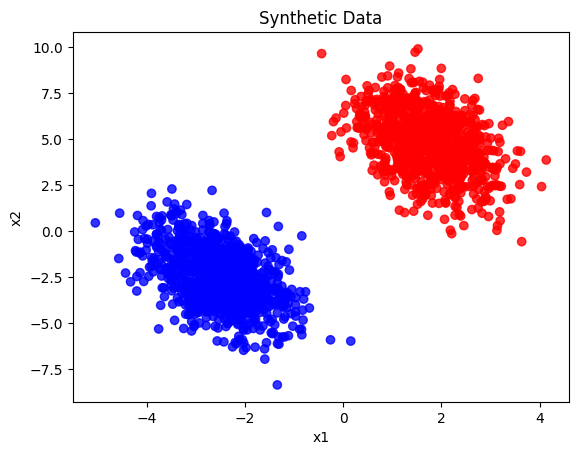

[[-2.19655439 -6.04817613]
 [ 0.81789766  4.8792503 ]
 [ 2.8314302   5.80299161]
 ...
 [-3.26670243 -2.62516778]
 [ 2.23050411  4.08324346]
 [ 0.81695873  4.89150137]]
[0 1 1 ... 0 1 1]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
 
# Generate synthetic data
np.random.seed(0)
centers = [[-5, 0], [5, 1.5]]
X, y = make_blobs(n_samples=2000, centers=centers, random_state=5)
transformation = [[0.5, 0.5], [-0.5, 1.5]]
X = np.dot(X, transformation)

plt.scatter(X[:,0], X[:,1], c=y, cmap="bwr", alpha=0.8)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Synthetic Data")
plt.show()

print(X)
print(y)